In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1788869650.451936 1332877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788869650.864040 1332877 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788869653.438747 1332877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Get the GPUs available.
tf.config.list_physical_devices("GPU")

W0000 00:00:1788869656.102504 1332877 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Model

In [3]:
# Define image size for using the model.
img_size = 224

In [4]:
# Load labels mapping.
with open("class_names.json", "r") as f:
    class_names = json.load(f)

In [5]:
# Load the pretrained model.
model = tf.keras.models.load_model("model.keras")

W0000 00:00:1788869656.674676 1332877 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788869657.227535 1332877 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


# Test

In [6]:
# Define an url to an image.
url = "https://emammal.si.edu/sites/default/files/aws_favorites/d45606s83i9.jpg"

In [7]:
path_image_test = keras.utils.get_file("image.jpg", origin=url, force_download=True)  # Saved to ~/.keras/datasets/image.jpg

177229/177229 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [8]:
img = keras.preprocessing.image.load_img(path_image_test, target_size=(img_size, img_size), color_mode="rgb", interpolation="bilinear")
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  

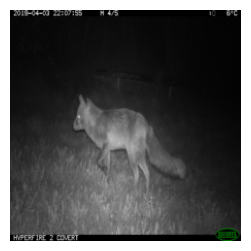

In [9]:
plt.figure(figsize = (3, 3))
plt.imshow(img_array.numpy().squeeze().astype("uint8"))
plt.axis("off");

In [10]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha = 0.5):
    # Load the original image
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img) 
    
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Display Grad CAM
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(superimposed_img)
    ax.axis("off")
    
    return fig

In [11]:
predictions = model.predict(img_array)

I0000 00:00:1788869666.865706 1332990 service.cc:153] XLA service 0x7f1cb806cc30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788869666.865790 1332990 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788869667.085242 1332990 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788869667.761152 1332990 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788869668.955362 1333068 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_160', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1788869669.099007 1333067 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_160', 96 bytes spill stores, 96 byte

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step


I0000 00:00:1788869688.051285 1332990 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [12]:
model.layers[-1].activation = None

In [13]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="convnext_base_stage_3_block_2_depthwise_conv")

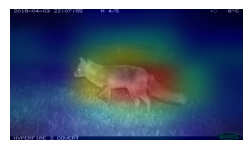

In [14]:
fig = display_gradcam(path_image_test, heatmap);

In [15]:
# Costruisci la stringa del testo dal tuo ciclo
text_str = ""
for idx in np.argsort(predictions[0])[-3:][::-1]:
    label_name = class_names[str(idx)]
    confidence = predictions[0][idx] * 100
    text_str += f"{label_name}: {confidence:.2f}%\n"

# Aggiungi il testo sotto l'immagine
fig.text(0.5, 0.1, text_str.strip(), ha="center", fontsize=9, family="monospace");

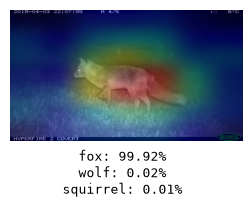

In [16]:
fig